In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))


TensorFlow version: 2.21.0
GPU available: []


In [2]:
data_dir = 'Gano-Cat-Breeds-V1_1'

# EfficientNetB3 expects 300x300
IMG_SIZE   = (300, 300)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
)

class_names = train_ds.class_names
NUM_CLASSES = len(class_names)
print(f"Classes ({NUM_CLASSES}):", class_names)


Found 5625 files belonging to 15 classes.
Using 4500 files for training.
Found 5625 files belonging to 15 classes.
Using 1125 files for validation.
Classes (15): ['Abyssinian', 'American Bobtail', 'American Shorthair', 'Bengal', 'Birman', 'Bombay', 'British Shorthair', 'Egyptian Mau', 'Maine Coon', 'Persian', 'Ragdoll', 'Russian Blue', 'Siamese', 'Sphynx', 'Tuxedo']


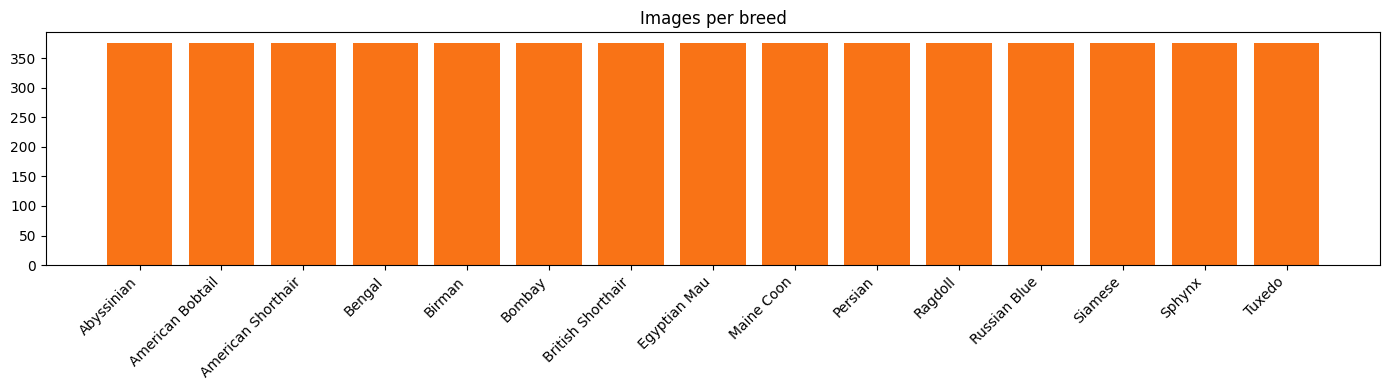


Class counts:
  Abyssinian                    : 375
  American Bobtail              : 375
  American Shorthair            : 375
  Bengal                        : 375
  Birman                        : 375
  Bombay                        : 375
  British Shorthair             : 375
  Egyptian Mau                  : 375
  Maine Coon                    : 375
  Persian                       : 375
  Ragdoll                       : 375
  Russian Blue                  : 375
  Siamese                       : 375
  Sphynx                        : 375
  Tuxedo                        : 375


In [3]:
# Check class distribution so we can spot imbalance early
import os, pathlib

class_counts = {}
data_path = pathlib.Path(data_dir)
for cls in class_names:
    cls_path = data_path / cls
    if cls_path.exists():
        count = len(list(cls_path.iterdir()))
        class_counts[cls] = count

plt.figure(figsize=(14, 4))
plt.bar(class_counts.keys(), class_counts.values(), color='#f97316')
plt.xticks(rotation=45, ha='right')
plt.title("Images per breed")
plt.tight_layout()
plt.show()

print("\nClass counts:")
for cls, count in sorted(class_counts.items(), key=lambda x: x[1]):
    print(f"  {cls:30s}: {count}")


In [4]:
import numpy as np
from sklearn.utils import class_weight

# Gather all labels from the training set to compute weights
all_labels = []
for _, labels in train_ds.unbatch():
    all_labels.append(labels.numpy())
all_labels = np.array(all_labels)

class_weights_array = class_weight.compute_class_weight(
    class_weight="balanced",
    classes=np.arange(NUM_CLASSES),
    y=all_labels,
)
class_weight_dict = dict(enumerate(class_weights_array))
print("Class weights computed:")
for idx, w in class_weight_dict.items():
    print(f"  {class_names[idx]:30s}: {w:.3f}")


Class weights computed:
  Abyssinian                    : 0.977
  American Bobtail              : 0.987
  American Shorthair            : 0.949
  Bengal                        : 0.984
  Birman                        : 1.027
  Bombay                        : 1.045
  British Shorthair             : 1.027
  Egyptian Mau                  : 0.968
  Maine Coon                    : 1.024
  Persian                       : 0.997
  Ragdoll                       : 1.038
  Russian Blue                  : 0.977
  Siamese                       : 0.977
  Sphynx                        : 0.977
  Tuxedo                        : 1.060


In [5]:
# Data augmentation — applied only on training data
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
    layers.RandomBrightness(0.15),
    layers.RandomContrast(0.15),
], name="augmentation")

# EfficientNetB3 has its own built-in preprocessing, so we pass raw [0,255] pixels.
# We only need to cast to float32.
def prepare_train(image, label):
    image = tf.cast(image, tf.float32)
    image = data_augmentation(image, training=True)
    return image, label

def prepare_val(image, label):
    image = tf.cast(image, tf.float32)
    return image, label

AUTOTUNE = tf.data.AUTOTUNE

train_ds_aug = (
    train_ds
    .map(prepare_train, num_parallel_calls=AUTOTUNE)
    .prefetch(AUTOTUNE)
)

val_ds_prep = (
    val_ds
    .map(prepare_val, num_parallel_calls=AUTOTUNE)
    .prefetch(AUTOTUNE)
)

print("Augmentation pipeline ready.")


Augmentation pipeline ready.


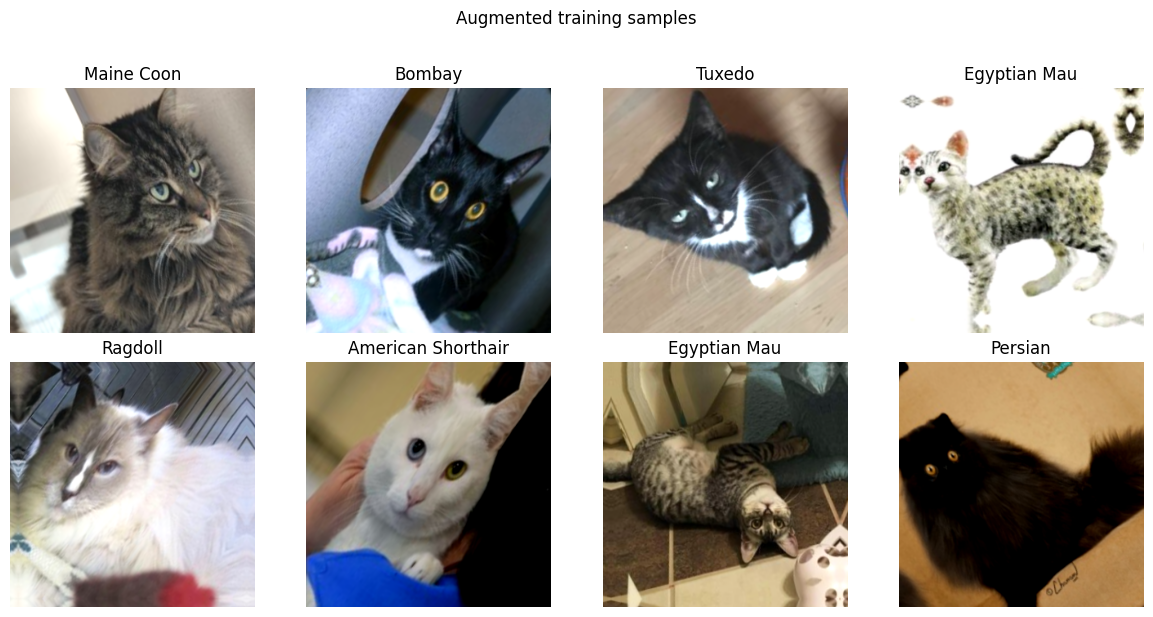

In [6]:
# Sanity check — visualise augmented samples
sample_images, sample_labels = next(iter(train_ds_aug))

plt.figure(figsize=(12, 6))
for i in range(8):
    ax = plt.subplot(2, 4, i + 1)
    img = sample_images[i].numpy().astype("uint8")
    plt.imshow(img)
    plt.title(class_names[sample_labels[i]])
    plt.axis("off")
plt.suptitle("Augmented training samples", y=1.02)
plt.tight_layout()
plt.show()


In [7]:
# Phase 1: freeze the EfficientNetB3 backbone and only train the head.
# This is critical — MobileNetV2 with trainable=True from epoch 1 at lr=0.01
# destroys the ImageNet features before the head has a chance to learn.

base_model = tf.keras.applications.EfficientNetB3(
    input_shape=(300, 300, 3),
    include_top=False,
    weights="imagenet",
)
base_model.trainable = False          # frozen for Phase 1
print(f"Base model parameters: {base_model.count_params():,}")

inputs  = tf.keras.Input(shape=(300, 300, 3))
x       = base_model(inputs, training=False)   # BN layers stay in inference mode
x       = layers.GlobalAveragePooling2D()(x)
x       = layers.BatchNormalization()(x)
x       = layers.Dense(256, activation="relu")(x)
x       = layers.Dropout(0.4)(x)
outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

model = tf.keras.Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

model.summary()


Base model parameters: 10,783,535


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 300, 300, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb3 (Functional)     │ (None, 10, 10, 1536)   │    10,783,535 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1536)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1536)           │         6,144 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       393,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 15)             │         3,855 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,187,006 (42.68 MB)

 Trainable params: 400,399 (1.53 MB)

 Non-trainable params: 10,786,607 (41.15 MB)

In [8]:
phase1_callbacks = [
    callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=5,
        restore_best_weights=True,
        verbose=1,
    ),
    callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1,
    ),
    callbacks.ModelCheckpoint(
        "best_phase1.keras",
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1,
    ),
]

print("=== Phase 1: Training head (backbone frozen) ===")
history1 = model.fit(
    train_ds_aug,
    validation_data=val_ds_prep,
    epochs=20,
    class_weight=class_weight_dict,
    callbacks=phase1_callbacks,
)


=== Phase 1: Training head (backbone frozen) ===
Epoch 1/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.5003 - loss: 1.7697
Epoch 1: val_accuracy improved from None to 0.77689, saving model to best_phase1.keras

Epoch 1: finished saving model to best_phase1.keras
141/141 ━━━━━━━━━━━━━━━━━━━━ 1432s 10s/step - accuracy: 0.6036 - loss: 1.3621 - val_accuracy: 0.7769 - val_loss: 0.7342 - learning_rate: 0.0010
Epoch 2/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7021 - loss: 0.9216
Epoch 2: val_accuracy improved from 0.77689 to 0.80178, saving model to best_phase1.keras

Epoch 2: finished saving model to best_phase1.keras
141/141 ━━━━━━━━━━━━━━━━━━━━ 526s 4s/step - accuracy: 0.7171 - loss: 0.8929 - val_accuracy: 0.8018 - val_loss: 0.5370 - learning_rate: 0.0010
Epoch 3/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7478 - loss: 0.7368
Epoch 3: val_accuracy improved from 0.80178 to 0.81511, saving model to best_phase1.keras

Epoch 3: finished saving model to be

In [9]:
# Phase 2: unfreeze the top layers of the backbone and fine-tune at a very low lr.
# Unfreezing ALL layers at once with a high lr would destroy the weights.

base_model.trainable = True

# Freeze everything except the last 40 layers
fine_tune_at = len(base_model.layers) - 40
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

trainable_count = sum(1 for l in base_model.layers if l.trainable)
print(f"Trainable backbone layers: {trainable_count} / {len(base_model.layers)}")

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),   # 100x smaller than Phase 1
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

phase2_callbacks = [
    callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=7,
        restore_best_weights=True,
        verbose=1,
    ),
    callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=4,
        min_lr=1e-7,
        verbose=1,
    ),
    callbacks.ModelCheckpoint(
        "best_phase2.keras",
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1,
    ),
]

print("\n=== Phase 2: Fine-tuning top backbone layers ===")
history2 = model.fit(
    train_ds_aug,
    validation_data=val_ds_prep,
    epochs=30,
    class_weight=class_weight_dict,
    callbacks=phase2_callbacks,
)


Trainable backbone layers: 40 / 385

=== Phase 2: Fine-tuning top backbone layers ===
Epoch 1/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.7224 - loss: 0.8155
Epoch 1: val_accuracy improved from None to 0.80889, saving model to best_phase2.keras

Epoch 1: finished saving model to best_phase2.keras
141/141 ━━━━━━━━━━━━━━━━━━━━ 698s 5s/step - accuracy: 0.7298 - loss: 0.7854 - val_accuracy: 0.8089 - val_loss: 0.6074 - learning_rate: 1.0000e-05
Epoch 2/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.7589 - loss: 0.7249
Epoch 2: val_accuracy did not improve from 0.80889
141/141 ━━━━━━━━━━━━━━━━━━━━ 671s 5s/step - accuracy: 0.7600 - loss: 0.7104 - val_accuracy: 0.8036 - val_loss: 0.6216 - learning_rate: 1.0000e-05
Epoch 3/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.7671 - loss: 0.6609
Epoch 3: val_accuracy did not improve from 0.80889
141/141 ━━━━━━━━━━━━━━━━━━━━ 599s 4s/step - accuracy: 0.7720 - loss: 0.6550 - val_accuracy: 0.8089 - val_loss: 0.6144 - learn

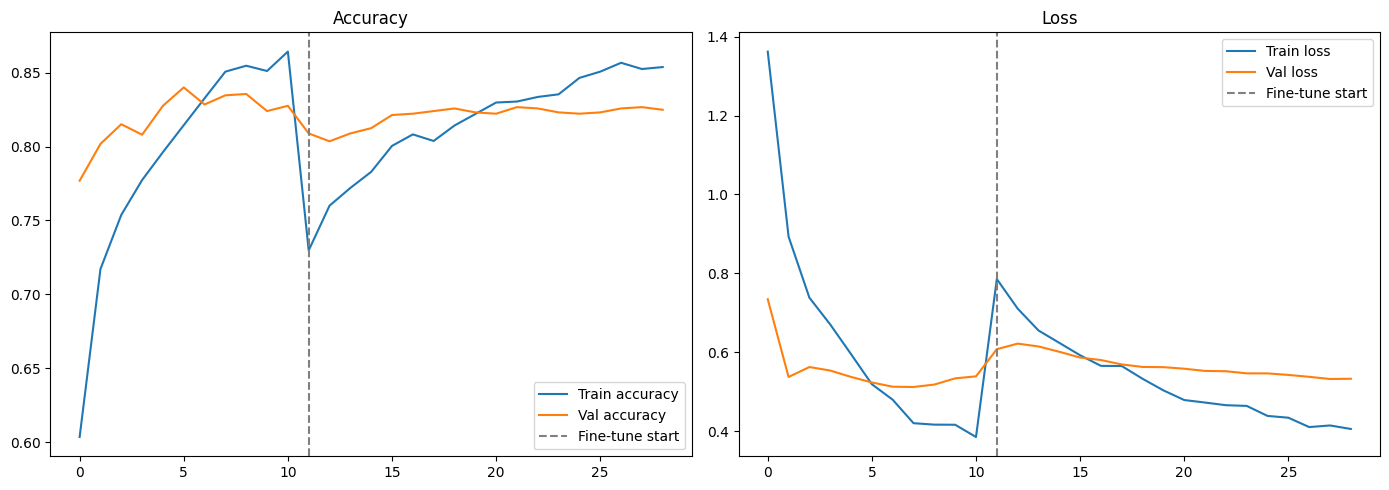

In [10]:
def plot_combined_history(h1, h2):
    acc      = h1.history["accuracy"]      + h2.history["accuracy"]
    val_acc  = h1.history["val_accuracy"]  + h2.history["val_accuracy"]
    loss     = h1.history["loss"]          + h2.history["loss"]
    val_loss = h1.history["val_loss"]      + h2.history["val_loss"]
    ep       = range(len(acc))
    split    = len(h1.history["accuracy"])

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.plot(ep, acc,     label="Train accuracy")
    ax1.plot(ep, val_acc, label="Val accuracy")
    ax1.axvline(split, color="gray", linestyle="--", label="Fine-tune start")
    ax1.set_title("Accuracy")
    ax1.legend()

    ax2.plot(ep, loss,     label="Train loss")
    ax2.plot(ep, val_loss, label="Val loss")
    ax2.axvline(split, color="gray", linestyle="--", label="Fine-tune start")
    ax2.set_title("Loss")
    ax2.legend()

    plt.tight_layout()
    plt.show()

plot_combined_history(history1, history2)



=== Classification Report ===
                    precision    recall  f1-score   support

        Abyssinian       0.74      0.93      0.82        68
  American Bobtail       0.63      0.38      0.47        71
American Shorthair       0.51      0.49      0.50        59
            Bengal       0.88      0.81      0.84        70
            Birman       0.73      0.76      0.75        83
            Bombay       0.89      0.92      0.91        88
 British Shorthair       0.80      0.84      0.82        83
      Egyptian Mau       0.75      0.74      0.74        65
        Maine Coon       0.81      0.89      0.85        82
           Persian       0.96      0.97      0.97        74
           Ragdoll       0.77      0.77      0.77        86
      Russian Blue       0.90      0.88      0.89        68
           Siamese       0.93      0.93      0.93        68
            Sphynx       0.99      0.99      0.99        68
            Tuxedo       0.98      0.99      0.98        92

       

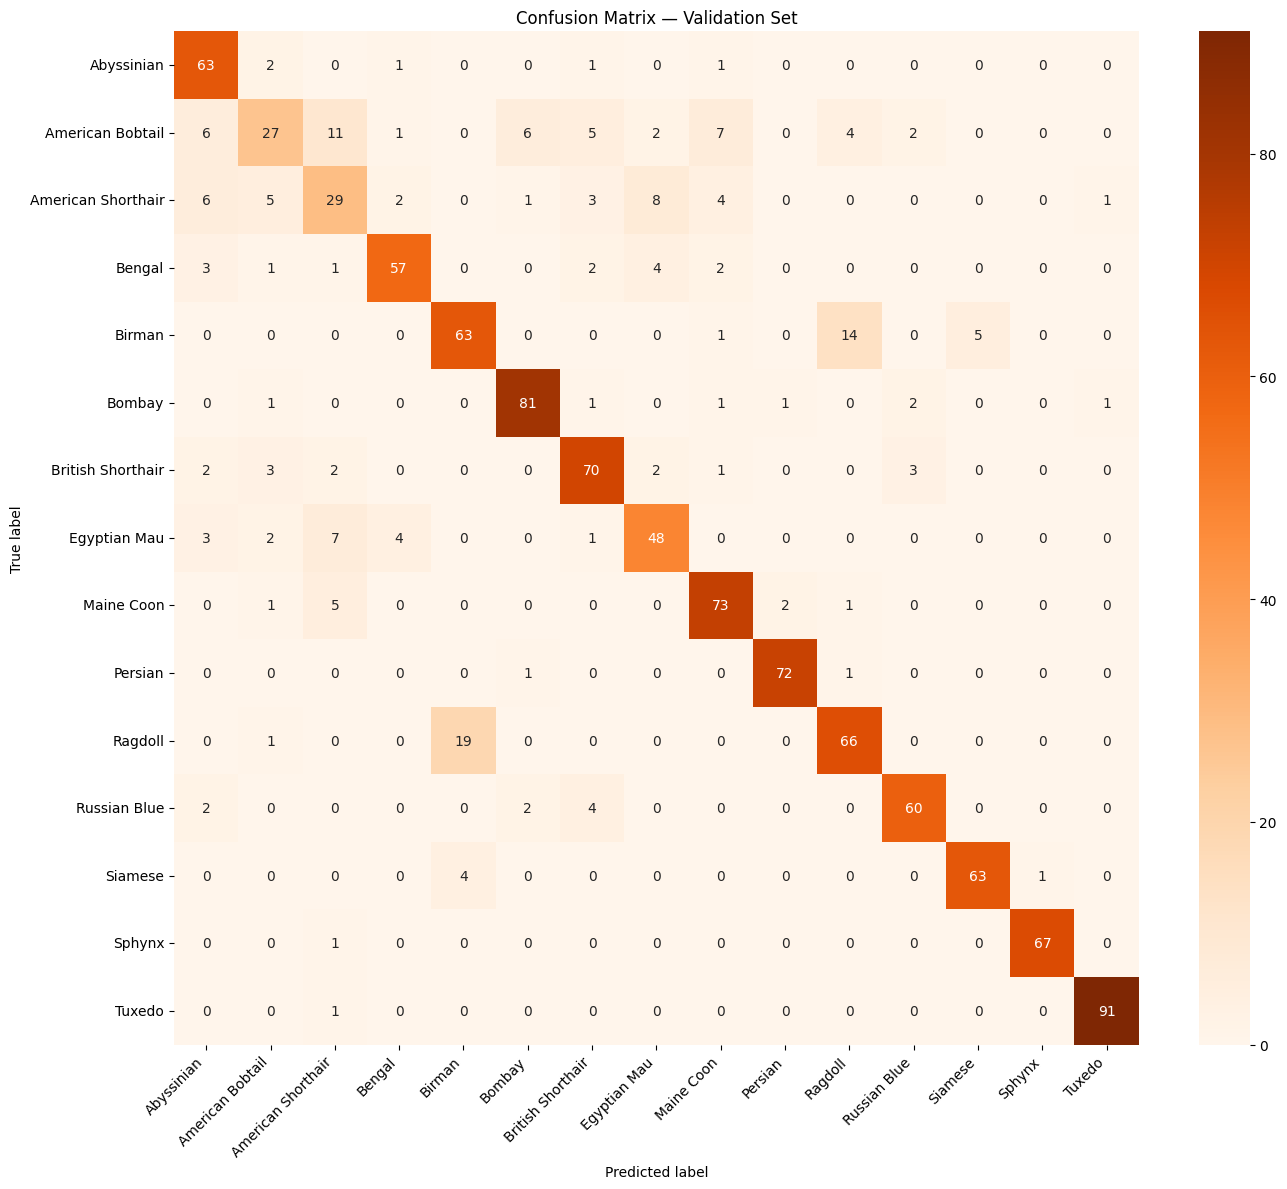

In [11]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Collect ground-truth and predictions from the validation set
y_true, y_pred = [], []
for images, labels in val_ds_prep:
    preds = model.predict(images, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels.numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("\n=== Classification Report ===")
print(classification_report(y_true, y_pred, target_names=class_names))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(14, 12))
sns.heatmap(
    cm, annot=True, fmt="d",
    xticklabels=class_names, yticklabels=class_names,
    cmap="Oranges",
)
plt.title("Confusion Matrix — Validation Set")
plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


In [12]:
# Save using the same filename your FastAPI backend expects
model.save("pet_identifier_model.keras")
np.save("cat_breeds_classes.npy", class_names)

print("✅ Model saved as  : pet_identifier_model.keras")
print("✅ Classes saved as: cat_breeds_classes.npy")
print(f"\nFinal validation accuracy: {max(history2.history['val_accuracy']):.4f}")


✅ Model saved as  : pet_identifier_model.keras
✅ Classes saved as: cat_breeds_classes.npy

Final validation accuracy: 0.8267
